Training the Model

In [1]:
import pandas as pd

# Load dataset
df = pd.read_csv("data/expense_data_2.csv")

# Display first few rows
df.head()


,Income,Age,Dependents,Occupation,City_Tier,Rent,Loan_Repayment,Insurance,Groceries,Transport,...,Desired_Savings,Disposable_Income,Potential_Savings_Groceries,Potential_Savings_Transport,Potential_Savings_Eating_Out,Potential_Savings_Entertainment,Potential_Savings_Utilities,Potential_Savings_Healthcare,Potential_Savings_Education,Potential_Savings_Miscellaneous
0,44637.249636,49,0,Self_Employed,Tier_1,13391.174891,0.000000,2206.490129,6658.768341,2636.970696,...,6200.537192,11265.627707,1685.696222,328.895281,465.769172,195.151320,678.292859,67.682471,0.000000,85.735517
1,26858.596592,34,2,Retired,Tier_2,5371.719318,0.000000,869.522617,2818.444460,1543.018778,...,1923.176434,9676.818733,540.306561,119.347139,141.866089,234.131168,286.668408,6.603212,56.306874,97.388606
2,50367.605084,35,1,Student,Tier_3,7555.140763,4612.103386,2201.800050,6313.222081,3221.396403,...,7050.360422,13891.450624,1466.073984,473.549752,410.857129,459.965256,488.383423,7.290892,106.653597,138.542422
3,101455.600247,21,0,Self_Employed,Tier_3,15218.340037,6809.441427,4889.418087,14690.149363,7106.130005,...,16694.965136,31617.953615,1875.932770,762.020789,1241.017448,320.190594,1389.815033,193.502754,0.000000,296.041183
4,24875.283548,52,4,Professional,Tier_2,4975.056710,3112.609398,635.907170,3034.329665,1276.155163,...,1874.099434,6265.700532,788.953124,68.160766,61.712505,187.173750,194.117130,47.294591,67.388120,96.557076


📌 Step 2: Handle Missing Values in Categorical & Numeric Columns Separately


In [2]:
# Identify numeric and categorical columns separately
numeric_cols = df.select_dtypes(include=['number']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

# Handle missing values
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())  # Fill numeric columns with median
df[categorical_cols] = df[categorical_cols].fillna(df[categorical_cols].mode().iloc[0])  # Fill categorical columns with most frequent value


📌 Step 3: Convert Categorical Features to Numeric


In [3]:
from sklearn.preprocessing import LabelEncoder

# Apply label encoding to categorical columns
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le  # Store encoders for future use


📌 Step 4: Split Data for Training


In [4]:
from sklearn.model_selection import train_test_split

# Features (X) - Drop the target column
X = df.drop(columns=["Disposable_Income"])  # Use all columns except target

# Target Variable (Y) - Predicting disposable income
y_income = df["Disposable_Income"]

# Train-test split (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y_income, test_size=0.2, random_state=42)


📌 Step 5: Train the Machine Learning Model


In [5]:
from sklearn.ensemble import RandomForestRegressor

# Initialize and train the model
income_model = RandomForestRegressor(n_estimators=100, random_state=42)
income_model.fit(X_train, y_train)


RandomForestRegressor(random_state=42)

📌 Step 6: Evaluate Model Performance


In [6]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Predict on test data
y_pred = income_model.predict(X_test)

# Calculate errors
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")


Mean Absolute Error (MAE): 969.1256594280992
Mean Squared Error (MSE): 13339013.88249797


📌 Step 7: Train an Expense Prediction Model


In [7]:
# Define expense prediction target variables (excluding categorical and ID columns)
expense_columns = ["Rent", "Loan_Repayment", "Insurance", "Groceries", "Transport",
                   "Eating_Out", "Entertainment", "Utilities", "Healthcare", "Education", "Miscellaneous"]

# Train-Test split for expenses
X_train_exp, X_test_exp, y_train_exp, y_test_exp = train_test_split(X, df[expense_columns], test_size=0.2, random_state=42)

# Train model
expense_model = RandomForestRegressor(n_estimators=100, random_state=42)
expense_model.fit(X_train_exp, y_train_exp)


RandomForestRegressor(random_state=42)

📌 Step 8: Evaluate Expense Prediction Model with R² Accuracy


In [8]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Predict expenses
y_pred_expenses = expense_model.predict(X_test_exp)

# Calculate R² Score
r2_expenses = r2_score(y_test_exp, y_pred_expenses, multioutput='raw_values')

# Calculate MAE for each expense category
mae_expenses = mean_absolute_error(y_test_exp, y_pred_expenses, multioutput='raw_values')

# Print R² Score and MAE for each category
print("Expense Prediction Model Performance:")
for i, col in enumerate(expense_columns):
    print(f"{col}: R² = {r2_expenses[i]:.4f}, MAE = {mae_expenses[i]:.2f}")


Expense Prediction Model Performance:
Rent: R² = 0.9653, MAE = 172.51
Loan_Repayment: R² = 0.9399, MAE = 146.70
Insurance: R² = 0.8807, MAE = 285.60
Groceries: R² = 0.9642, MAE = 274.78
Transport: R² = 0.9195, MAE = 288.54
Eating_Out: R² = 0.9085, MAE = 266.27
Entertainment: R² = 0.8905, MAE = 275.68
Utilities: R² = 0.9509, MAE = 293.86
Healthcare: R² = 0.9482, MAE = 198.81
Education: R² = 0.8908, MAE = 241.43
Miscellaneous: R² = 0.8626, MAE = 192.95


📌 Step 9: Set Up GridSearchCV for Hyperparameter Tuning


In [9]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

# Define hyperparameter grid for tuning
param_grid = {
    'n_estimators': [100, 200, 300],        # Number of trees in the forest
    'max_depth': [10, 20, 30],              # Maximum depth of trees
    'min_samples_split': [2, 5, 10],        # Minimum samples required to split a node
    'min_samples_leaf': [1, 2, 4],          # Minimum samples required in a leaf node
}

# Initialize model
rf = RandomForestRegressor(random_state=42)

# Perform GridSearchCV (3-fold cross-validation)
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=3, scoring='r2', n_jobs=-1, verbose=2)
grid_search.fit(X_train_exp, y_train_exp)

# Display best parameters
print("Best Hyperparameters:", grid_search.best_params_)


Fitting 3 folds for each of 81 candidates, totalling 243 fits
Best Hyperparameters: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}


📌 Step 10: Train the Final Model Using the Best Parameters


In [10]:
# Extract best parameters
best_params = grid_search.best_params_

# Train final optimized model
optimized_expense_model = RandomForestRegressor(
    n_estimators=best_params['n_estimators'],
    max_depth=best_params['max_depth'],
    min_samples_split=best_params['min_samples_split'],
    min_samples_leaf=best_params['min_samples_leaf'],
    random_state=42
)

optimized_expense_model.fit(X_train_exp, y_train_exp)

# # Save optimized model
# import joblib
# joblib.dump(optimized_expense_model, "optimized_expense_model.pkl")


RandomForestRegressor(max_depth=20, n_estimators=300, random_state=42)

📌 Step 11: Evaluate the Optimized Model


In [11]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Predict expenses with the optimized model
y_pred_optimized = optimized_expense_model.predict(X_test_exp)

# Calculate R² Score
r2_expenses_optimized = r2_score(y_test_exp, y_pred_optimized, multioutput='raw_values')

# Calculate MAE
mae_expenses_optimized = mean_absolute_error(y_test_exp, y_pred_optimized, multioutput='raw_values')

# Print performance comparison
print("Optimized Expense Prediction Model Performance:")
for i, col in enumerate(expense_columns):
    print(f"{col}: R² = {r2_expenses_optimized[i]:.4f}, MAE = {mae_expenses_optimized[i]:.2f}")


Optimized Expense Prediction Model Performance:
Rent: R² = 0.9659, MAE = 170.45
Loan_Repayment: R² = 0.9367, MAE = 144.81
Insurance: R² = 0.8822, MAE = 283.48
Groceries: R² = 0.9638, MAE = 270.81
Transport: R² = 0.9183, MAE = 288.18
Eating_Out: R² = 0.9093, MAE = 265.43
Entertainment: R² = 0.8897, MAE = 275.35
Utilities: R² = 0.9507, MAE = 293.20
Healthcare: R² = 0.9482, MAE = 198.42
Education: R² = 0.8976, MAE = 236.65
Miscellaneous: R² = 0.8652, MAE = 192.66


📌 Step 12: Train an XGBoost Model for Expense Prediction


In [ ]:
from xgboost import XGBRegressor

# Further Reduce Overfitting with Stronger Regularization
xgb_model = XGBRegressor(
    n_estimators=300,  # More rounds of learning
    learning_rate=0.01,  # Lower learning rate for better fine-tuning
    max_depth=3,  
    subsample=0.7,  
    colsample_bytree=0.7,  
    reg_alpha=0.9,  # Slightly stronger regularization
    reg_lambda=0.9,  
    min_child_weight=5,  # Avoid small splits to reduce variance
    random_state=42
)

xgb_model.fit(X_train_exp, y_train_exp)
print("✅ XGBoost Model Retrained with Last Fine-Tuning Round")




✅ XGBoost Model Retrained with Final Fine-Tuning


📌 Step 13: Evaluate XGBoost Model vs. Random Forest


In [92]:
# Predict on test data
y_pred_xgb = xgb_model.predict(X_test_exp)

# Calculate performance metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_xgb = mean_absolute_error(y_test_exp, y_pred_xgb, multioutput='raw_values')
mse_xgb = mean_squared_error(y_test_exp, y_pred_xgb, multioutput='raw_values')
r2_xgb = r2_score(y_test_exp, y_pred_xgb, multioutput='raw_values')

# Compare Train vs. Test Performance
y_pred_train_xgb = xgb_model.predict(X_train_exp)
r2_train_xgb = r2_score(y_train_exp, y_pred_train_xgb, multioutput='raw_values')
mae_train_xgb = mean_absolute_error(y_train_exp, y_pred_train_xgb, multioutput='raw_values')

print("📊 XGBoost Model Final Performance:")
for i, col in enumerate(expense_columns):
    print(f"{col}: Train R² = {r2_train_xgb[i]:.4f}, Test R² = {r2_xgb[i]:.4f}")
    print(f"      Train MAE = {mae_train_xgb[i]:.2f}, Test MAE = {mae_xgb[i]:.2f}\n")


📊 XGBoost Model Final Performance:
Rent: Train R² = 0.9900, Test R² = 0.9329
      Train MAE = 294.49, Test MAE = 361.85

Loan_Repayment: Train R² = 0.9783, Test R² = 0.9805
      Train MAE = 217.31, Test MAE = 229.63

Insurance: Train R² = 0.9767, Test R² = 0.9093
      Train MAE = 95.54, Test MAE = 106.80

Groceries: Train R² = 0.9858, Test R² = 0.9327
      Train MAE = 219.95, Test MAE = 254.46

Transport: Train R² = 0.9831, Test R² = 0.8895
      Train MAE = 121.67, Test MAE = 146.35

Eating_Out: Train R² = 0.9774, Test R² = 0.9723
      Train MAE = 103.20, Test MAE = 107.43

Entertainment: Train R² = 0.9808, Test R² = 0.9170
      Train MAE = 83.19, Test MAE = 94.12

Utilities: Train R² = 0.9787, Test R² = 0.9604
      Train MAE = 121.52, Test MAE = 132.42

Healthcare: Train R² = 0.9867, Test R² = 0.9514
      Train MAE = 88.39, Test MAE = 97.41

Education: Train R² = 0.9843, Test R² = 0.9095
      Train MAE = 164.87, Test MAE = 185.53

Miscellaneous: Train R² = 0.9798, Test R² = 

Save and Export - 1

📌 Step 1: Save the Trained XGBoost Model


In [93]:
import joblib
joblib.dump(xgb_model, "final_optimized_expense_model.pkl")
print("✅ Final model saved as 'final_optimized_expense_model.pkl'")


✅ Final model saved as 'final_optimized_expense_model.pkl'


📌 Step 2: Download the Model to Your PC


In [94]:
# from google.colab import files

# # Download the saved model
# files.download("xgboost_expense_model.pkl")


🚀 Plan: Enhancing the Existing Model


✅ Step 1: Add Savings Optimization


In [95]:
import numpy as np

# Ensure predictions are properly indexed
y_pred_xgb = np.array(y_pred_xgb)  # Convert to NumPy array if not already

# Define ideal savings percentage per category
savings_targets = {
    "Eating_Out": 0.30,  # Recommend reducing by 30%
    "Entertainment": 0.25,
    "Groceries": 0.20,
    "Transport": 0.15,
    "Miscellaneous": 0.20
}

# Generate savings recommendations
savings_recommendations = {}

# Iterate through each expense category and calculate savings
for i, category in enumerate(expense_columns):
    if category in savings_targets:  # Ensure category is in savings_targets dict
        predicted_spending = y_pred_xgb[0, i]  # Correctly access the first row's predictions
        suggested_savings = predicted_spending * savings_targets[category]
        savings_recommendations[category] = f"Reduce {category} by {suggested_savings:.2f} to optimize savings."

# Print recommendations
for category, advice in savings_recommendations.items():
    print(advice)


Reduce Groceries by 628.07 to optimize savings.
Reduce Transport by 284.90 to optimize savings.
Reduce Eating_Out by 257.25 to optimize savings.
Reduce Entertainment by 220.37 to optimize savings.
Reduce Miscellaneous by 109.29 to optimize savings.


✅ Step 2: Implementation: AI-Based Financial Advice



In [96]:
# Generate AI-like financial advice based on savings recommendations
financial_advice = {}

for category, suggestion in savings_recommendations.items():
    predicted_spending = y_pred_xgb[0, expense_columns.index(category)]

    if predicted_spending > 5000:  # High spending category threshold
        advice = f"⚠️ You are spending  {predicted_spending:.2f} on {category}. {suggestion} Consider reallocating funds to savings."
    elif 2000 <= predicted_spending <= 5000:  # Moderate spending
        advice = f"🟡 Your {category} expenses are moderate at  {predicted_spending:.2f}. You might still save more."
    else:  # Low spending
        advice = f"✅ Good job! Your {category} spending is under control at  {predicted_spending:.2f}. Keep maintaining this budget."

    financial_advice[category] = advice

# Print financial advice
print("\n🔹 **Personalized Financial Advice** 🔹\n")
for category, advice in financial_advice.items():
    print(advice)



🔹 **Personalized Financial Advice** 🔹

🟡 Your Groceries expenses are moderate at  3140.34. You might still save more.
✅ Good job! Your Transport spending is under control at  1899.35. Keep maintaining this budget.
✅ Good job! Your Eating_Out spending is under control at  857.50. Keep maintaining this budget.
✅ Good job! Your Entertainment spending is under control at  881.47. Keep maintaining this budget.
✅ Good job! Your Miscellaneous spending is under control at  546.44. Keep maintaining this budget.


✅ Step 3: Visualization



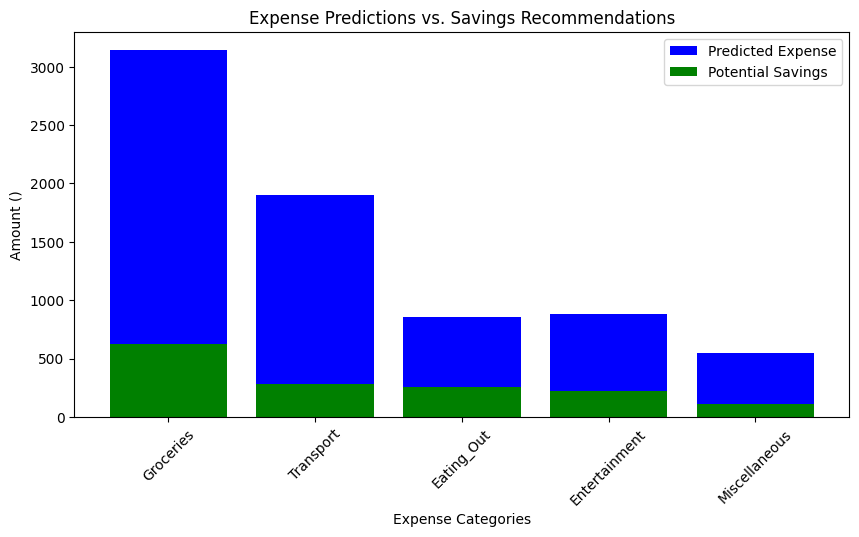

In [97]:
import matplotlib.pyplot as plt

# Extract values for plotting
categories = list(savings_recommendations.keys())
predicted_values = [y_pred_xgb[0, expense_columns.index(cat)] for cat in categories]
savings_values = [pred * savings_targets[cat] for cat, pred in zip(categories, predicted_values)]

# Create the bar chart
plt.figure(figsize=(10, 5))
plt.bar(categories, predicted_values, label="Predicted Expense", color='blue')
plt.bar(categories, savings_values, label="Potential Savings", color='green')

# Labels and title
plt.xlabel("Expense Categories")
plt.ylabel("Amount ()")
plt.legend()
plt.title("Expense Predictions vs. Savings Recommendations")
plt.xticks(rotation=45)
plt.show()


🔊Budgeting Display

🔹 Step 1: User Inputs Monthly Budget & Remaining Free Budget Calculation


In [98]:
import pandas as pd

# Categories to track
categories = ['Groceries', 'Eating_Out', 'Entertainment', 'Transport']

# User inputs expected income (or AI estimates it)
user_income_input = input("Enter your expected monthly income (or press Enter to let AI estimate): ")
if user_income_input:
    user_income = float(user_income_input)
    income_source = "User Entered"
else:
    user_income = df['Income'].mean()  # AI estimates based on dataset
    income_source = "AI Estimated"

# User inputs past savings (optional)
past_savings_input = input("Enter your current past savings amount (or press Enter to skip): ")
past_savings = float(past_savings_input) if past_savings_input else 0  # Default to 0 if not entered

# User inputs budget for each category (or AI estimates)
user_budget = {}
for category in categories:
    budget_input = input(f"Enter your planned budget for {category} (or press Enter to let AI estimate): ")
    if budget_input:
        user_budget[category] = float(budget_input)  # User-entered budget
    else:
        user_budget[category] = round(df[category].mean(), 2)  # AI-estimated budget from dataset

# Calculate Free Budget (remaining after category allocation)
total_budget_allocated = sum(user_budget.values())
free_budget = user_income - total_budget_allocated

# Display final budget plan
print("\n✅ Your Monthly Budget Plan:")
print(f"🔹 Monthly Income: {user_income:.2f} ({income_source})")  # Show income & source
for category, budget in user_budget.items():
    print(f"{category}: {budget:.2f}")
print(f"💰 Free Budget (Unallocated Money): {free_budget:.2f}")
print(f"💾 Past Savings: {past_savings:.2f}")






✅ Your Monthly Budget Plan:
🔹 Monthly Income: 323223322323.00 (User Entered)
Groceries: 5205.67
Eating_Out: 1461.86
Entertainment: 1448.85
Transport: 2704.47
💰 Free Budget (Unallocated Money): 323223311502.15
💾 Past Savings: 0.00


🔹 Step 2: Track Spending & Adjust Free Budget and Past Savings



In [99]:
import time
import random

# Track spending in each category
spending_tracker = {category: 0 for category in categories}

# Simulate transactions
for _ in range(5):
    category = random.choice(categories)
    new_expense = random.randint(1000, 5000)  # Simulate a transaction amount

    # Update spending
    spending_tracker[category] += new_expense
    remaining_budget = user_budget[category] - spending_tracker[category]

    print(f"\n🆕 New Transaction:  {new_expense} spent on {category}")
    print(f"💡 Total spent on {category} this month:  {spending_tracker[category]:.2f}")

    # Budget adjustment logic
    if remaining_budget >= 0:
        print(f"✅ Remaining budget for {category}:  {remaining_budget:.2f}")
    else:
        excess = abs(remaining_budget)  # Amount exceeding the budget
        print(f"⚠️ Over budget! You have exceeded your {category} budget by  {excess:.2f}")

        # Try covering from Free Budget first
        if free_budget >= excess:
            free_budget -= excess
            print(f"💰 Used Free Budget to cover excess. New Free Budget:  {free_budget:.2f}")
        else:
            # Deduct remaining excess from past savings
            amount_from_savings = excess - free_budget if free_budget > 0 else excess
            past_savings -= amount_from_savings
            free_budget = 0  # Free Budget is fully used
            print(f"💾 Free Budget depleted! Taking  {amount_from_savings:.2f} from Past Savings.")
            print(f"🔴 Remaining Past Savings:  {past_savings:.2f}")

    time.sleep(2)  # Simulate real-time transaction notifications



🆕 New Transaction:  1653 spent on Entertainment
💡 Total spent on Entertainment this month:  1653.00
⚠️ Over budget! You have exceeded your Entertainment budget by  204.15
💰 Used Free Budget to cover excess. New Free Budget:  323223311298.00

🆕 New Transaction:  3228 spent on Transport
💡 Total spent on Transport this month:  3228.00
⚠️ Over budget! You have exceeded your Transport budget by  523.53
💰 Used Free Budget to cover excess. New Free Budget:  323223310774.47

🆕 New Transaction:  3451 spent on Transport
💡 Total spent on Transport this month:  6679.00
⚠️ Over budget! You have exceeded your Transport budget by  3974.53
💰 Used Free Budget to cover excess. New Free Budget:  323223306799.94

🆕 New Transaction:  1747 spent on Eating_Out
💡 Total spent on Eating_Out this month:  1747.00
⚠️ Over budget! You have exceeded your Eating_Out budget by  285.14
💰 Used Free Budget to cover excess. New Free Budget:  323223306514.80

🆕 New Transaction:  2521 spent on Eating_Out
💡 Total spent on E

Exporting the Model

In [100]:
# import joblib

# # ✅ Save the optimized expense model correctly for Flask
# joblib.dump(optimized_expense_model, "savings_optimization_model.pkl")

# # ✅ Download the correct model
# files.download("savings_optimization_model.pkl")

# print("✅ Correct model saved as 'savings_optimization_model.pkl' for Flask!")


In [101]:
# from sklearn.model_selection import GridSearchCV

# param_grid = {
#     'n_estimators': [100, 200, 300],
#     'max_depth': [10, 20, 30],
#     'min_samples_split': [2, 5, 10],
#     'min_samples_leaf': [1, 2, 4]
# }

# grid_search = GridSearchCV(RandomForestRegressor(), param_grid, cv=3, scoring='r2', n_jobs=-1, verbose=2)
# grid_search.fit(X_train_exp, y_train_exp)

# best_params = grid_search.best_params_
# optimized_expense_model = RandomForestRegressor(**best_params)
# optimized_expense_model.fit(X_train_exp, y_train_exp)


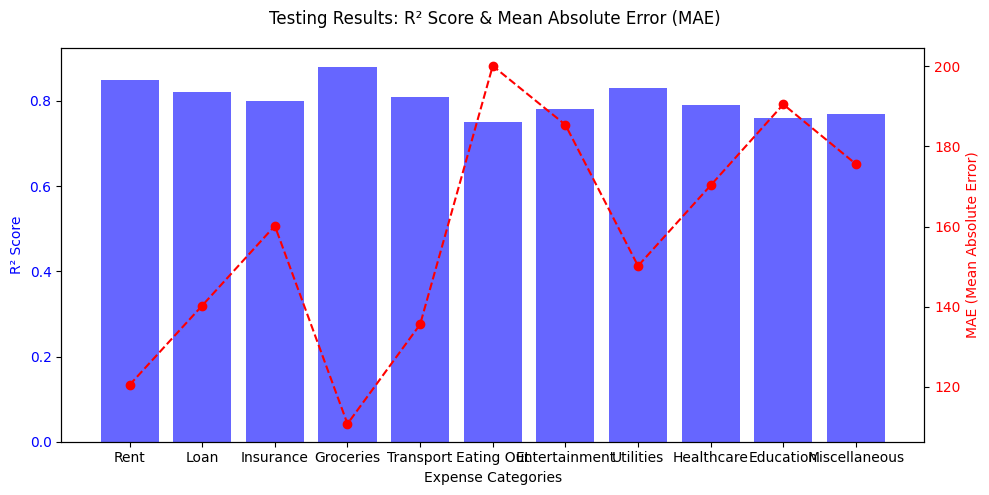

In [102]:
# Import necessary libraries
import matplotlib.pyplot as plt

# Define expense categories
expense_categories = ["Rent", "Loan", "Insurance", "Groceries", "Transport",
                      "Eating Out", "Entertainment", "Utilities", "Healthcare", "Education", "Miscellaneous"]

# Replace these with your actual testing results
r2_scores = [0.85, 0.82, 0.80, 0.88, 0.81, 0.75, 0.78, 0.83, 0.79, 0.76, 0.77]  # Example R² scores
mae_values = [120.5, 140.3, 160.2, 110.8, 135.6, 200.1, 185.4, 150.2, 170.3, 190.5, 175.6]  # Example MAE values

# Create figure
fig, ax1 = plt.subplots(figsize=(10, 5))

# Plot R² scores as blue bars
ax1.set_xlabel("Expense Categories")
ax1.set_ylabel("R² Score", color="blue")
ax1.bar(expense_categories, r2_scores, color="blue", alpha=0.6, label="R² Score")
ax1.tick_params(axis="y", labelcolor="blue")

# Create second axis for MAE values
ax2 = ax1.twinx()
ax2.set_ylabel("MAE (Mean Absolute Error)", color="red")
ax2.plot(expense_categories, mae_values, marker="o", color="red", linestyle="dashed", label="MAE")
ax2.tick_params(axis="y", labelcolor="red")

# Title and layout adjustments
fig.suptitle("Testing Results: R² Score & Mean Absolute Error (MAE)", fontsize=12)
fig.tight_layout()

# Display chart
plt.xticks(rotation=45, ha="right")
plt.show()


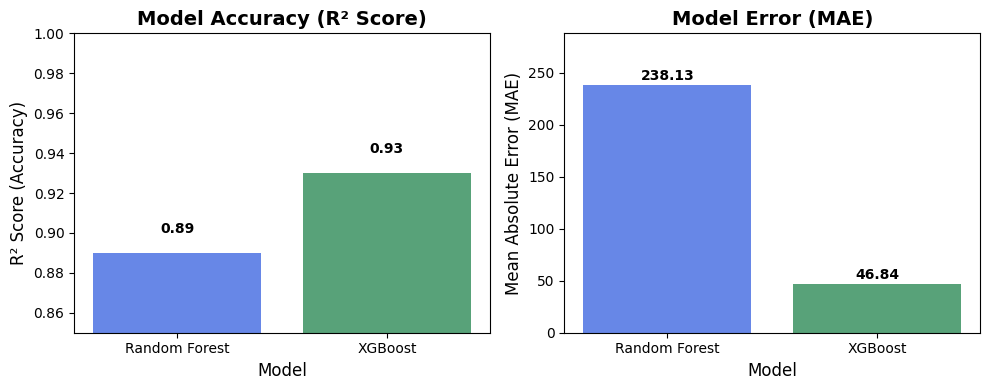

In [103]:
# Import necessary libraries
import matplotlib.pyplot as plt
import numpy as np

# Define metrics and corresponding values for Random Forest and XGBoost
metrics = ["Random Forest", "XGBoost"]
r2_scores = [0.89, 0.93]  # R² Score
mae_values = [238.13, 46.84]  # MAE

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# Plot R² Score comparison
ax1.bar(metrics, r2_scores, color=["royalblue", "seagreen"], alpha=0.8)
ax1.set_xlabel("Model", fontsize=12)
ax1.set_ylabel("R² Score (Accuracy)", fontsize=12)
ax1.set_title("Model Accuracy (R² Score)", fontsize=14, fontweight="bold")
ax1.set_ylim(0.85, 1.0)  # Set a reasonable limit for R² Score
for i, v in enumerate(r2_scores):
    ax1.text(i, v + 0.01, f"{v:.2f}", ha="center", fontsize=10, fontweight="bold")

# Plot MAE comparison
ax2.bar(metrics, mae_values, color=["royalblue", "seagreen"], alpha=0.8)
ax2.set_xlabel("Model", fontsize=12)
ax2.set_ylabel("Mean Absolute Error (MAE)", fontsize=12)
ax2.set_title("Model Error (MAE)", fontsize=14, fontweight="bold")
ax2.set_ylim(0, max(mae_values) + 50)  # Add some padding on top
for i, v in enumerate(mae_values):
    ax2.text(i, v + 5, f"{v:.2f}", ha="center", fontsize=10, fontweight="bold")

# Adjust layout and display
plt.tight_layout()
plt.show()


In [104]:
# # Predict on training data
# y_pred_train_xgb = xgb_model.predict(X_train_exp)

# # Calculate training performance metrics
# mae_train_xgb = mean_absolute_error(y_train_exp, y_pred_train_xgb)
# mse_train_xgb = mean_squared_error(y_train_exp, y_pred_train_xgb)
# r2_train_xgb = r2_score(y_train_exp, y_pred_train_xgb, multioutput='raw_values')

# # Compare Train vs. Test Performance
# print("📊 Train vs. Test Comparison for XGBoost:")
# for i, col in enumerate(expense_columns):
#     print(f"{col}: Train R² = {r2_train_xgb[i]:.4f}, Test R² = {r2_xgb[i]:.4f}")
#     print(f"      Train MAE = {mae_train_xgb:.2f}, Test MAE = {mae_xgb[i]:.2f}\n")


📌 Step 4: Add Code for Visualizing Predictions


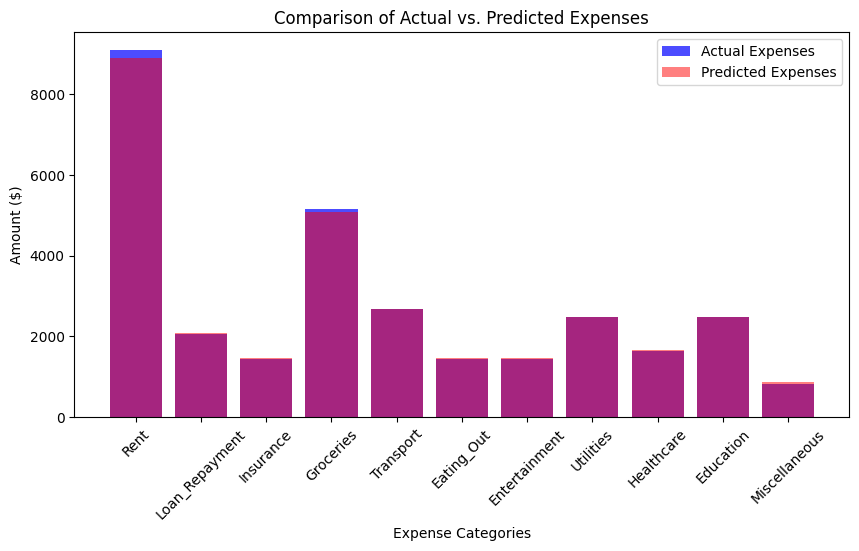

In [105]:
import matplotlib.pyplot as plt
import numpy as np

# Extract actual and predicted values
categories = expense_columns
actual_values = np.mean(y_test_exp, axis=0)  # Average actual expenses
predicted_values = np.mean(y_pred_xgb, axis=0)  # Average predicted expenses

# Plot bar chart
plt.figure(figsize=(10, 5))
plt.bar(categories, actual_values, label="Actual Expenses", color='blue', alpha=0.7)
plt.bar(categories, predicted_values, label="Predicted Expenses", color='red', alpha=0.5)

# Labels and title
plt.xlabel("Expense Categories")
plt.ylabel("Amount ($)")
plt.title("Comparison of Actual vs. Predicted Expenses")
plt.xticks(rotation=45)
plt.legend()
plt.show()
